# Напишите заголовок проекта здесь

- Автор: Горюнова Полина
- Дата: 15.07.2026

### Цели и задачи проекта

<font color='#777778'>

Провести исследовательский анализ рынка общественного питания Москвы на основе данных Яндекс Карт и Яндекс Бизнес за лето 2022 года, чтобы помочь инвесторам из фонда Shut Up and Take My Money выбрать оптимальный формат, локацию и ценовую политику для открытия нового заведения. В ходе анализа мы изучим структуру рынка по категориям, соотношение сетевых и несетевых заведений, распределение средних чеков и рейтингов по районам Москвы, выявим факторы, влияющие на успешность заведений, и на основе полученных данных сформулируем практические рекомендации по открытию нового проекта с максимальными шансами на успех.</font>

### Описание данных

<font color='#777778'>В работе используются два датасета с заведениями общественного питания Москвы на основе данных Яндекс Карт и Яндекс Бизнес за лето 2022 года. Первый файл rest_info.csv содержит информацию о 4058 заведениях: название (name), адрес (address), административный район (district), категория (category), график работы (hours), рейтинг от 1 до 5 (rating), признак сети (0 или 1) (chain) и количество посадочных мест (seats). Второй файл rest_price.csv предоставляет данные о ценообразовании: ценовая категория (price), текстовое описание среднего чека (avg_bill) и его числовая оценка (middle_avg_bill), а также стоимость чашки кофе (middle_coffee_cup) </font>

### Содержимое проекта

<font color='#777778'>

1. Загрузка данных и знакомство с ними
Загрузка двух датасетов (rest_info.csv и rest_price.csv), изучение общей информации, проверка объёма данных, типов, пропусков и соответствия описанию, объединение в единый датафрейм.

2. Предобработка данных
Преобразование типов данных, обработка пропусков (заполнение или удаление), проверка и удаление дубликатов, нормализация текстовых полей, создание нового столбца is_24_7 для круглосуточных заведений.

3. Исследовательский анализ данных
Анализ категорий заведений, распределения по районам (особенно Центральный округ), соотношения сетевых и несетевых заведений, количества посадочных мест, рейтингов и их корреляции с другими признаками, выделение топ-15 сетей по популярности, изучение цен в разрезе районов и удалённости от центра.

4. Итоговый вывод и рекомендации
Формулировка общих выводов по рынку общепита Москвы и практических рекомендаций для инвесторов: оптимальный формат заведения, перспективные районы, ценовая политика и другие ключевые параметры для успешного открытия.</font>


## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.

In [2]:
# Используйте ячейки типа Code для вашего кода

In [3]:
# При необходимости добавьте новые ячейки для кода или удалите пустые

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
!pip install phik

     |████████████████████████████████| 677 kB 1.9 MB/s eta 0:00:01


In [5]:
#Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

In [6]:
info_df = pd.read_csv('/datasets/rest_info.csv')
price_df = pd.read_csv('/datasets/rest_price.csv')

In [7]:
#Информация об основном датасете
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [8]:
#Первые пять строк основного датасета
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [9]:
#Информация о ценовом датасете
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [10]:
#Первые пять строк ценового датасета
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Нам предоставлены два датасета: первы1 (rest_info.csv) с 8406 записями и 9 колонками, и второй (rest_price.csv) с 4058 записями и 5 колонками. Данные в целом соответствуют описанию, но требуют предобработки: в первом датасете присутствуют пропуски в столбцах hours (6.4%) и seats (43%), а в ценовом датасете — в price (18.3%), middle_avg_bill (22.4%) и middle_coffee_cup (86.8%, что делает эту колонку практически бесполезной). Также необходимо преобразовать типы данных:  chain, category — в категориальные. 

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [11]:
#Объединение двух датасетов по id
df = info_df.merge(price_df, on='id', how='left')

In [12]:
print("Процент потерянных данных при объединении таблиц:",round((len(info_df)-len(df))/len(info_df)*100,2), "%")

Процент потерянных данных при объединении таблиц: 0.0 %


In [13]:
#Информация об объединеном датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [14]:
#Его первые пять строк
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [15]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [16]:
#Преобразуем в категорию
df['chain'] = df['chain'].astype('category')
df['category'] = df['category'].astype('category')
for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [17]:
#Проверка преобразований
print(df.dtypes)

id                     object
name                   object
category             category
address                object
district               object
hours                  object
rating                float32
chain                category
seats                 float32
price                  object
avg_bill               object
middle_avg_bill       float32
middle_coffee_cup     float32
dtype: object


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [18]:
#Пропущенные значения для каждого столбца
for column in df:
    print(f'{column}: {df[column].isna().sum()}')

id: 0
name: 0
category: 0
address: 0
district: 0
hours: 536
rating: 0
chain: 0
seats: 3611
price: 5091
avg_bill: 4590
middle_avg_bill: 5257
middle_coffee_cup: 7871


In [19]:
#Доли
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [20]:
# Комментарий ревьюера
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


In [21]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(a, b, round((a-b)/a*100, 2))

8406 8406 0.0


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [22]:
# 1. Явные (полные) дубликаты
full_duplicates = df.duplicated().sum()
print(f"Явных дубликатов: {full_duplicates}")

# 2. Неявные (по названию и адресу)
partial_duplicates = df.duplicated(subset=['name', 'address']).sum()
print(f"Неявных дубликатов (по названию+адресу): {partial_duplicates}")


Явных дубликатов: 0
Неявных дубликатов (по названию+адресу): 0


In [23]:

# Нормализуем названия и адреса
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

# Ищем неявные дубликаты
partial_duplicates = df[df.duplicated(subset=['name', 'address'], keep=False)]
print(f"Неявных дубликатов (по названию и адресу): {len(partial_duplicates)}")

if len(partial_duplicates) > 0:
    print("Примеры неявных дубликатов:")
    print(partial_duplicates[['name', 'address', 'rating']].head())
    
# Удаляем неявные дубликаты
    df = df.drop_duplicates(subset=['name', 'address'], keep='first')
    print(f"После удаления неявных дубликатов: {len(df)} записей")

Неявных дубликатов (по названию и адресу): 8
Примеры неявных дубликатов:
                           name                                  address  \
189                        кафе             москва, парк ангарские пруды   
215                        кафе             москва, парк ангарские пруды   
1430                  more poke  москва, волоколамское шоссе, 11, стр. 2   
1511                  more poke  москва, волоколамское шоссе, 11, стр. 2   
2211  раковарня клешни и хвосты               москва, проспект мира, 118   

      rating  
189      3.2  
215      3.2  
1430     4.2  
1511     4.2  
2211     4.4  
После удаления неявных дубликатов: 8402 записей


In [24]:
#Проверяем, что дубликатов больше нет
partial_duplicates_after = df[df.duplicated(subset=['name', 'address'], keep=False)]
print(len(partial_duplicates_after))

0


In [25]:
#Уникальные значения
for column in ['name', 'address']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце name:
['#кешбэккафе' '+39 pizzeria mozzarella bar' '1 этаж' ... 'ё-ланч'
 'ёж и устрица' 'ёрш']

Уникальные значения в столбце address:
['москва, 1-й автозаводский проезд, 5'
 'москва, 1-й балтийский переулок, 3/25'
 'москва, 1-й варшавский проезд, 1ас9' ...
 'москва, яузский бульвар, 11, стр. 1' 'москва, яузский бульвар, 14/8'
 'москва, № 7']



In [26]:
#Количество уникальных значений
print(f"Уникальных названий: {df['name'].nunique()}")
print(f"Уникальных адресов: {df['address'].nunique()}")

Уникальных названий: 5512
Уникальных адресов: 5752


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [27]:
#Создание нового столбца
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

# Проверяем
print(df['is_24_7'].value_counts())


False    7672
True      730
Name: is_24_7, dtype: int64


In [28]:
#Количество круглосуточных заведений
df['is_24_7'].sum()

730

In [29]:
# Комментарий ревьюера
# Проверим правильность категоризации
tmp0, col1 = df.copy(), 'is_24_7'
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

print(" Количество не работающих ежедневно и круглосуточно", a1,
      '\n', "Количество работающих ежедневно и круглосуточно", a2,'\n')
print("Количество категорий полученное в проекте:")
try:
    print(tmp0[col1].value_counts())
except:
    print("Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.")

 Количество не работающих ежедневно и круглосуточно 7672 
 Количество работающих ежедневно и круглосуточно 730 

Количество категорий полученное в проекте:
False    7672
True      730
Name: is_24_7, dtype: int64


In [30]:
#Проверка
df[df['is_24_7']==1]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN,True
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",Северный административный округ,"ежедневно, круглосуточно",4.4,0,96.0,средние,Средний счёт:350–500 ₽,425.0,NaN,True
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN,True
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",Северный административный округ,"ежедневно, круглосуточно",4.0,1,NaN,NaN,NaN,NaN,NaN,True
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",Северный административный округ,"ежедневно, круглосуточно",2.7,0,NaN,NaN,Средний счёт:900 ₽,900.0,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8394,03c53ed5236948179947b46b7338d18d,намангале,кафе,"москва, ферганская улица, вл17-21",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.3,0,NaN,NaN,NaN,NaN,NaN,True
8399,71cc394927204d45b81c3a91edb47955,"пекарня, кафе-гриль",булочная,"москва, болотниковская улица, 52, корп. 2",Юго-Западный административный округ,"ежедневно, круглосуточно",4.2,0,50.0,NaN,Средний счёт:50–250 ₽,150.0,NaN,True
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN,True
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана sabr,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN,True


In [31]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

В ходе предобработки был сформирован объединённый датасет размером 8 406 строк × 13 колонок, содержащий информацию о заведениях общественного питания Москвы: название, адрес, район, категория, часы работы, рейтинг, признак сети, количество мест, ценовая категория и средний чек. После всех преобразований датасет сохранил размер 8 402 строки × 15 колонок. Выполнено приведение типов данных: колонки chain и category преобразованы в категориальный тип, а числовые колонки (rating, middle_avg_bill, middle_coffee_cup, seats) — в float32, что обеспечило корректность всех типов для дальнейшего анализа. Пропуски сохранены для предотвращения потери значимых данных. Явных дубликатов не обнаружено, а 8 неявных дубликатов по паре «название + адрес» были удалены. Для дальнейшего анализа создан новый признак: is_24_7 (круглосуточная работа), а также были нормализованны колонки name и address. Итоговый датасет содержит 8 402 строки.

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [32]:
#Уникальные категории
df['category'].unique()

['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']

In [33]:
#Количество
df['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [34]:
#Количество
df['category'].value_counts(normalize=True)

кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64

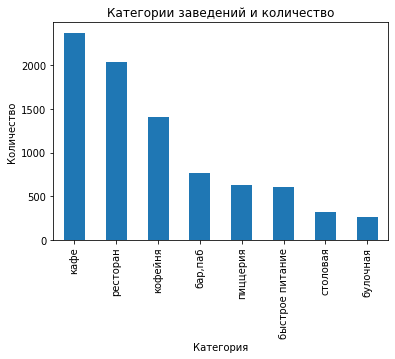

In [35]:
#Визуал по абсолютному количеству
df['category'].value_counts().plot(
kind='bar',
title = 'Категории заведений и количество',
xlabel = 'Категория',
ylabel = 'Количество')
plt.show()

В данных представлено 8 категорий заведений: кафе, рестораны, кофейни, бары и пабы, пиццерии, заведения быстрого питания, столовые и булочные. Наиболее многочисленными являются кафе (2 376 заведений, 28.3% рынка), рестораны (2 042, 24.3%) и кофейни (1 413, 16.8%). Бары и пабы составляют 9.1%, пиццерии — 7.5%, быстрое питание — 7.2%, столовые — 3.7%, а булочные — 3% рынка. Таким образом, рынок сильно сегментирован и основная доля приходится на три крупнейшие категории.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [36]:
#Районы
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [37]:
#Количество заведений в разных районах - абсолютные значения
regions = df.groupby('district')['name'].count()
print(regions)

district
Восточный административный округ            798
Западный административный округ             850
Северный административный округ             898
Северо-Восточный административный округ     890
Северо-Западный административный округ      409
Центральный административный округ         2242
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Южный административный округ                892
Name: name, dtype: int64


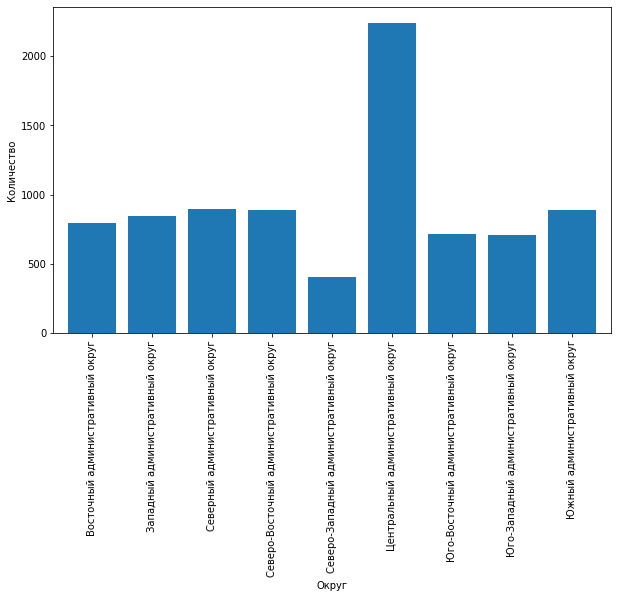

In [38]:
#Визуал
regions.plot(
kind='bar',
xlabel = 'Округ',
ylabel = 'Количество',
figsize=(10,6),
width=0.8)
plt.show()

In [39]:
#Доли
regions_pct = regions / regions.sum().round(2)
print(regions_pct)

district
Восточный административный округ           0.094977
Западный административный округ            0.101166
Северный административный округ            0.106879
Северо-Восточный административный округ    0.105927
Северо-Западный административный округ     0.048679
Центральный административный округ         0.266841
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Южный административный округ               0.106165
Name: name, dtype: float64


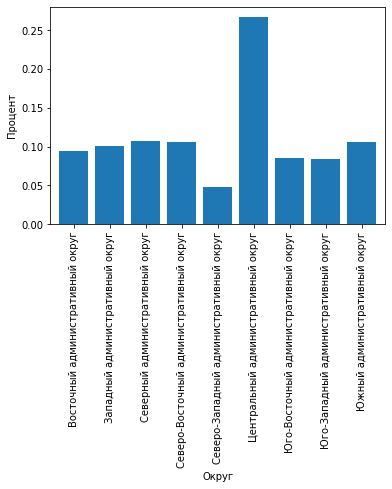

In [40]:
#Визуал
regions_pct.plot(
kind='bar',
xlabel = 'Округ',
ylabel = 'Процент',
width=0.8)
plt.show()

In [41]:
#Ценатральный округ
central = df[df['district'] == 'Центральный административный округ'].groupby('category').size()
central = central.sort_values(ascending=False)
print (central)

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
dtype: int64


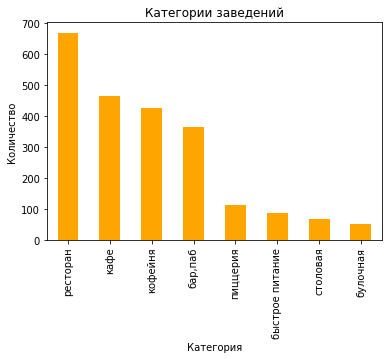

In [42]:
#Визуал центрального округа
central.plot(
kind='bar',
title = 'Категории заведений',
xlabel = 'Категория',
ylabel = 'Количество',
color = 'orange')
plt.show()

In [43]:
#Доли
central_pct = central / central.sum().round(2)
central_pct = central_pct.sort_values(ascending=False)
print(central_pct)

category
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
dtype: float64


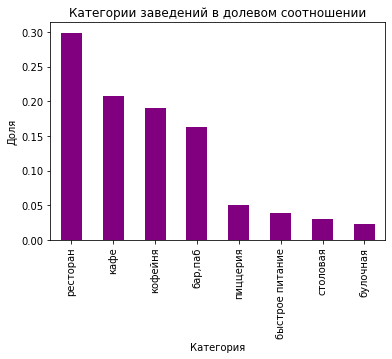

In [44]:
#Визуал центрального округа в долевом соотношении
central_pct.plot(
kind='bar',
title = 'Категории заведений в долевом соотношении',
xlabel = 'Категория',
ylabel = 'Доля',
color = 'purple')
plt.show()

Районы в данных: Северный административный округ,
       Северо-Восточный административный округ,
       Северо-Западный административный округ,
       Западный административный округ,
       Центральный административный округ,
       Восточный административный округ,
       Юго-Восточный административный округ,
       Южный административный округ,
       Юго-Западный административный округ
       
       
       
Центральный район характеризуется высоким разнообразием и концентрацией заведений, где доминируют рестораны, кафе и кофейни.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [45]:
#Количество несетевых
no = len(df[df['chain']==0])
print(no)

5199


In [46]:
#Доля несетевых
no_pct = no/len(df)
print (no_pct)

0.618781242561295


In [47]:
#Количество сетевых
yes = len(df[df['chain']==1])
print(yes)

3203


In [48]:
#Доля сетевых
yes_pct = yes/len(df)
print (yes_pct)

0.3812187574387051


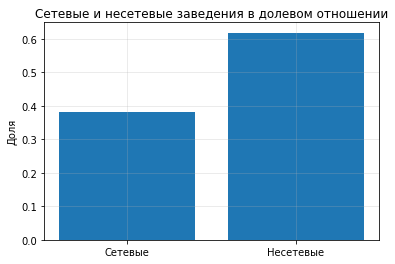

In [49]:
#Визуал
plt.bar(['Сетевые', 'Несетевые'], [yes_pct, no_pct])
plt.title('Сетевые и несетевые заведения в долевом отношении')
plt.grid(alpha=0.3)
plt.ylabel('Доля')
plt.show()

In [50]:
#Создаём числовую колонку
df['chain_num'] = df['chain'].astype('int')

category_chain = df.groupby('category')['chain_num'].agg(
    total='count',
    chain='sum'
)

category_chain['chain_pct'] = (category_chain['chain'] / category_chain['total']).round(2)
category_chain = category_chain.sort_values('chain_pct', ascending=False)
print(category_chain)

                 total  chain  chain_pct
category                                
булочная           256    157       0.61
пиццерия           633    330       0.52
кофейня           1413    720       0.51
быстрое питание    603    232       0.38
ресторан          2042    729       0.36
кафе              2376    779       0.33
столовая           315     88       0.28
бар,паб            764    168       0.22


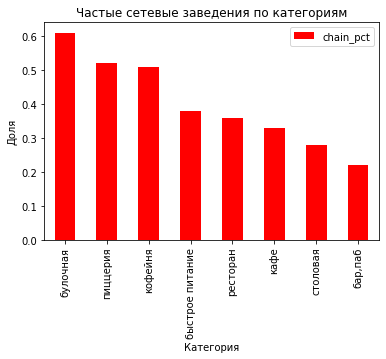

In [51]:
#Визуал
category_chain.plot(kind = 'bar', color ='red', title = 'Частые сетевые заведения по категориям', ylabel ='Доля',xlabel = 'Категория', y = 'chain_pct')
plt.show()

Анализ показал, что в Москве преобладают несетевые заведения, которые составляют около 60% от всех объектов. Наиболее высокая доля сетевых заведений наблюдается в булочных (61%), пиццериях (52%) и кофейнях (51%). В быстром питании доля сетей составляет 38%, в ресторанах — 36%, в кафе — 33%. Наименьшая доля сетевых заведений зафиксирована в столовых (28%) и барах и пабах (22%). Таким образом, наиболее перспективными для открытия сетевого заведения являются сегменты булочных, пиццерий и кофеен, тогда как бары, пабы и столовые остаются преимущественно несетевыми.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


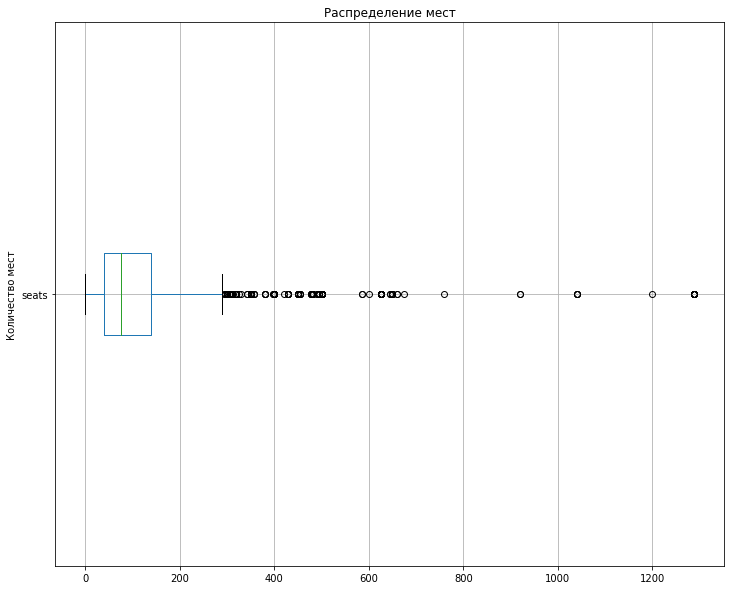

In [52]:
df['seats'].plot(kind='box', title ='Распределение мест', ylabel='Количество мест', figsize=(12,10), grid = True, vert=False)
plt.show()

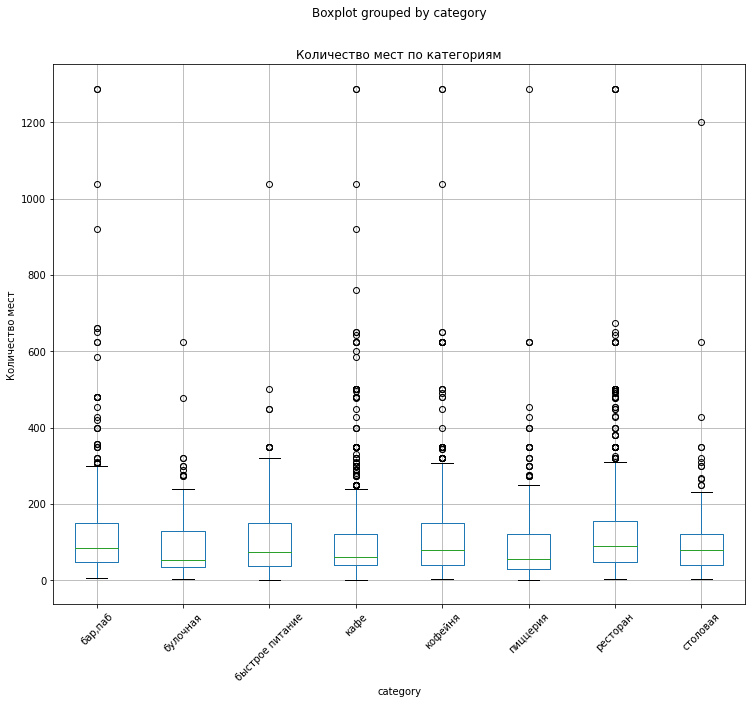

In [53]:
#Боксплот по каждой категории
df[df['seats'] > 0].boxplot(column='seats', by='category', figsize=(12, 10))
plt.title('Количество мест по категориям')
plt.xticks(rotation=45)
plt.ylabel('Количество мест')
plt.show()

In [54]:
# Статистика по местам 
print(df['seats'].describe())

# Сколько заведений с местами до 20
small = df[df['seats'] <= 20].shape[0]
total = df[df['seats'] >= 0].shape[0]
print(f"Заведений с местами <= 20: {small} ({small/total*100:.1f}%)")

# Проверим максимум
max_seats = df['seats'].max()
print(f"Максимум мест: {max_seats}")

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64
Заведений с местами <= 20: 631 (13.2%)
Максимум мест: 1288.0


In [55]:
#Наиболее частое количество мест в каждой категории
seats_typ = df[df['seats']>=0].groupby('category')['seats'].agg(pd.Series.median)
seats_typ = seats_typ.sort_values(ascending=False)
print(seats_typ)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float32


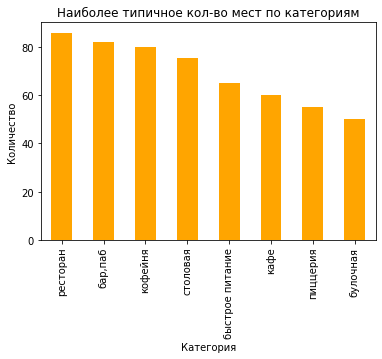

In [56]:
seats_typ.plot(kind = 'bar', color = 'orange', title = 'Наиболее типичное кол-во мест по категориям', ylabel = 'Количество', xlabel = 'Категория')
plt.show()

В данных встречаются выбросы — максимальное количество мест составляет 1 288, что значительно превышает средние значения и характерно для крупных ресторанов, банкетных залов или фудкортов. Среднее количество мест (около 108) заметно выше медианы (75), что подтверждает влияние выбросов на среднюю оценку. При этом только 13.2% заведений имеют не более 20 посадочных мест, а основная масса объектов сосредоточена в диапазоне от 40 до 140 мест. Наиболее типичное количество мест варьируется по категориям: у ресторанов в среднем 86 мест, у баров и пабов — 82, у кофеен — 80, у столовых — около 76, у заведений быстрого питания — 65, у кафе — 60, у пиццерий — 55, а у булочных — 50 мест. Таким образом, в Москве преобладают заведения среднего размера, а крупные площадки встречаются редко и являются скорее исключением.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [57]:
rate = df.groupby('category')['rating'].describe()
rate.sort_values('count', ascending = False)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0


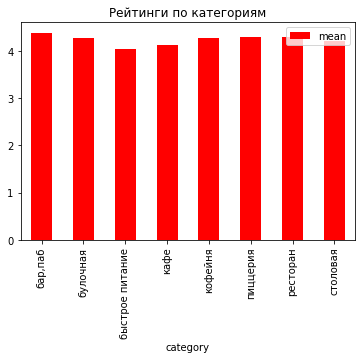

In [58]:
rate.plot(kind = 'bar', title = 'Рейтинги по категориям', color = 'red', y = 'mean')

    
plt.show()

Средние рейтинги заведений варьируются от 4.05 (быстрое питание) до 4.39 (бары и пабы). Разница между лучшими и худшими категориями составляет около 0.34 балла, что указывает на реальные различия в качестве обслуживания и уровне удовлетворённости клиентов. Наиболее высокие и стабильные оценки получают бары, пабы, пиццерии и рестораны. Самые низкие и нестабильные — кафе и быстрое питание. 

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [59]:
for_corr = ['category', 'district', 'rating', 'chain', 'seats', 'price', 'is_24_7']
corr_matrix = df[for_corr].phik_matrix()
corr_matrix


interval columns not set, guessing: ['rating', 'seats']


,category,district,rating,chain,seats,price,is_24_7
category,1.000000,0.174584,0.198739,0.266000,0.048923,0.566933,0.244815
district,0.174584,1.000000,0.189453,0.064473,0.352440,0.202787,0.076357
rating,0.198739,0.189453,1.000000,0.118857,0.000000,0.262056,0.161010
chain,0.266000,0.064473,0.118857,1.000000,0.056523,0.218211,0.043488
seats,0.048923,0.352440,0.000000,0.056523,1.000000,0.088146,0.043193
price,0.566933,0.202787,0.262056,0.218211,0.088146,1.000000,0.084183
is_24_7,0.244815,0.076357,0.161010,0.043488,0.043193,0.084183,1.000000


In [60]:
rate_corr = corr_matrix['rating'].sort_values(ascending=False)
rate_corr 

rating      1.000000
price       0.262056
category    0.198739
district    0.189453
is_24_7     0.161010
chain       0.118857
seats       0.000000
Name: rating, dtype: float64

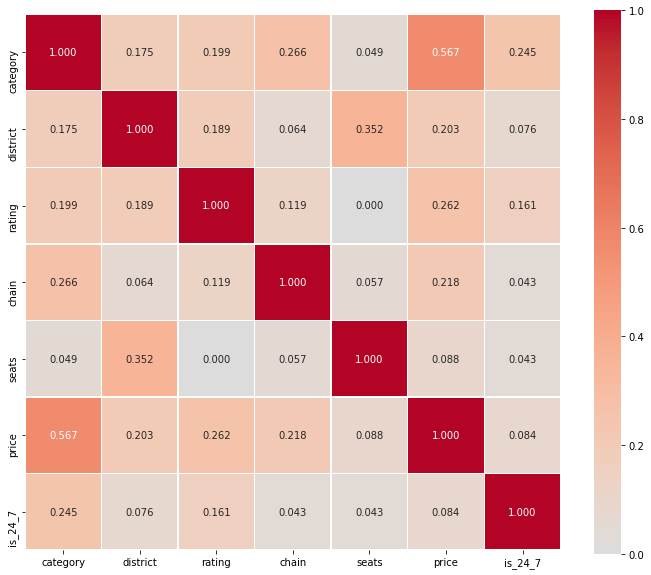

In [61]:
#Визуал
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=0.5)
plt.show()

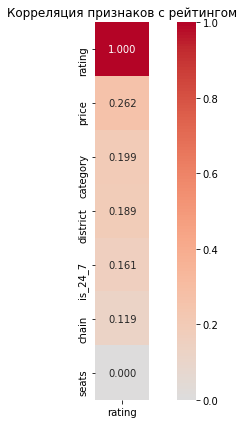

In [62]:
#Визуал отдельно для рейтинга
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['rating']].sort_values(by='rating', ascending=False), 
            annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Корреляция признаков с рейтингом')
plt.tight_layout()
plt.show()

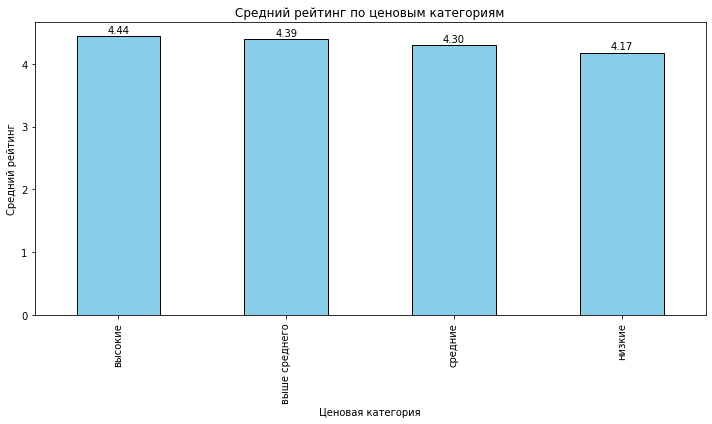

In [63]:
#Самая сильная связь у рейтинга и цены, визуализация

# Группируем и считаем средний рейтинг
price_rating = df.groupby('price')['rating'].mean().sort_values(ascending=False)

plt.grid(axis='y', alpha=0.3)
price_rating.plot(kind = 'bar', figsize = (10,6), color='skyblue', edgecolor='black', title = 'Средний рейтинг по ценовым категориям',
xlabel = 'Ценовая категория', ylabel ='Средний рейтинг')

for i, v in enumerate(price_rating):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

На рейтинг заведения слабо влияют цена, категория и район.
Самый заметный признак — цена: более дорогие заведения в среднем имеют чуть более высокий рейтинг.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [64]:
# Фильтруем только сетевые заведения
networks = df[df['chain'] == 1]

# Группируем по названию
top15_networks = networks.groupby('name').agg(
    count=('name', 'count'),
    avg_rating=('rating', 'mean'),
    category=('category', 'first') 
).sort_values('count', ascending=False).head(15)

top15_networks

,count,avg_rating,category
name,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,76,4.169737,пиццерия
додо пицца,74,4.286487,пиццерия
one price coffee,71,4.064789,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,быстрое питание
кофепорт,42,4.147619,кофейня


In [69]:
# Комментарий ревьюера 2
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


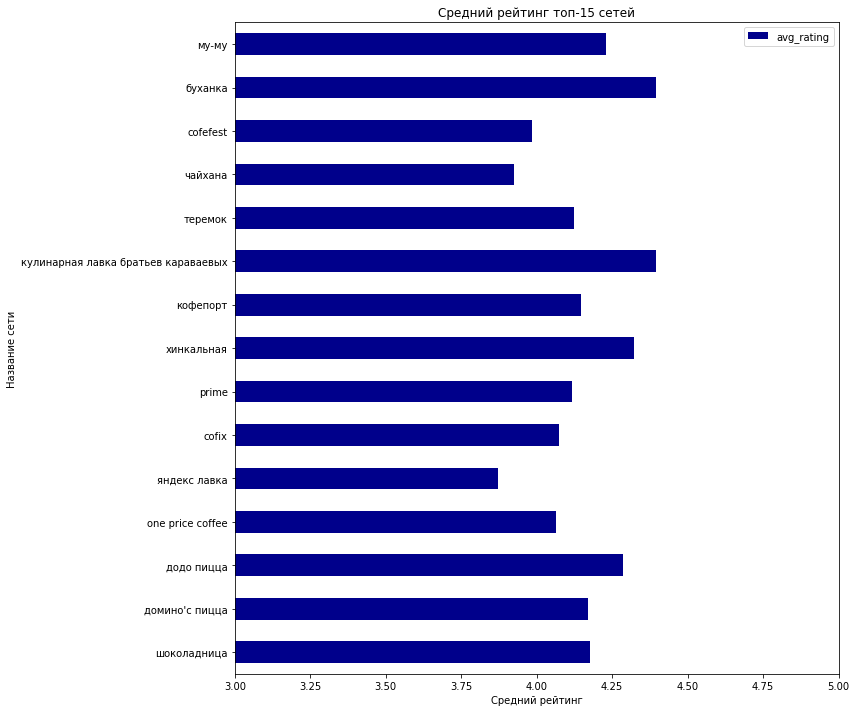

In [65]:
#Визуал сеть - рейтинг
top15_networks.plot(kind='barh', y = 'avg_rating', figsize = (12,10), color = 'darkblue')
plt.title('Средний рейтинг топ-15 сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xlim(3.0, 5.0)
plt.tight_layout()
plt.show()
plt.show()

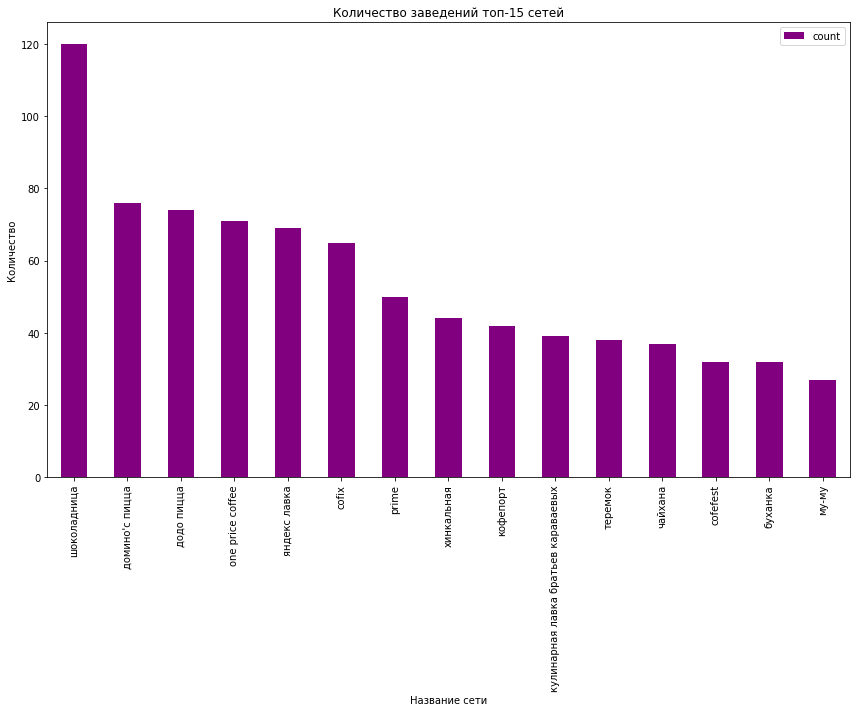

In [66]:
#Визуал сеть - рейтинг
top15_networks.plot(kind='bar', y = 'count', figsize = (12,10), color = 'purple')
plt.title('Количество заведений топ-15 сетей')
plt.ylabel('Количество')
plt.xlabel('Название сети')
plt.tight_layout()
plt.show()
plt.show()

Среди топ-15 сетевых заведений Москвы лидируют кофейни (шоколадница, one price coffee, cofix, кофепорт, cofefest) и пиццерии (домино'с, додо), на их долю приходится основная часть крупных сетей. Самая большая сеть — шоколадница (120 точек), самый высокий рейтинг среди топ-15 у буханки (4.40) и кулинарной лавки братьев Караваевых (4.39). Средний рейтинг большинства сетей находится в диапазоне 4.0–4.3.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [67]:
#Группировка
var = df.groupby('district')['middle_avg_bill'].describe()
var


,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
Восточный административный округ,260.0,820.626953,850.903320,50.0,338.00,575.0,1100.0,10000.0
Западный административный округ,306.0,1053.225464,779.008484,50.0,427.50,1000.0,1500.0,5250.0
Северный административный округ,322.0,927.959656,912.609192,130.0,350.00,650.0,1250.0,11000.0
Северо-Восточный административный округ,301.0,716.611267,591.232117,50.0,325.00,500.0,950.0,4500.0
Северо-Западный административный округ,157.0,822.222900,595.055237,120.0,340.00,700.0,1100.0,2900.0
Центральный административный округ,1060.0,1191.057495,920.014709,0.0,500.00,1000.0,1500.0,7250.0
Юго-Восточный административный округ,194.0,654.097961,566.825684,30.0,281.25,450.0,887.5,3750.0
Юго-Западный административный округ,235.0,792.561707,559.173096,100.0,350.00,600.0,1100.0,2750.0
Южный административный округ,314.0,834.398071,2008.640625,100.0,350.00,500.0,1037.5,35000.0


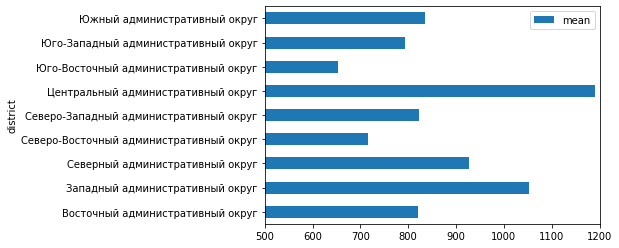

In [68]:
#Визуал по среднему чеку
var.plot(kind = 'barh', xlim=(500,1200), y = 'mean')
plt.show()

В Центральном округе средний чек самый высокий — 1 191 ₽, что заметно выше, чем в других районах (в среднем ~811 ₽). Самые низкие цены — в Юго-Восточном (654 ₽) и Северо-Восточном (717 ₽) округах. При этом медиана в центре (1000 ₽) тоже выше, чем в большинстве районов (500–700 ₽). Самый большой разброс цен — в Южном округе (есть заведения до 35 000 ₽). Удалённость от центра слабо влияет на цены: чем дальше, тем чуть дешевле, но есть исключения (например, Западный округ с ценами почти как в центре).

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

Рынок общепита Москвы преимущественно несетевой (61%) — лидируют кафе, рестораны и кофейни.
Центр — самая дорогая и насыщенная зона: средний чек там 1 190 ₽, что выше, чем в спальных районах.
Рейтинг почти не зависит от цены, формата или сети.
Большинство заведений — небольшие (до 80 мест), круглосуточных — всего 8.5%.
Среди сетей популярнее всего кофейни (шоколадница — 120 филиалов) 

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.


В ходе исследования был проведён анализ рынка общественного питания Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Были обработаны два датасета с информацией о заведениях, проведена предобработку данных и выполнен исследовательский анализ по ключевым параметрам: категории заведений, их расположению по районам, сетевой принадлежности, количеству посадочных мест, рейтингам и средним чекам. По итогам работы сформулированы основные выводы и практические рекомендации для инвесторов.

Анализ показал, что рынок общественного питания Москвы представлен преимущественно несетевыми заведениями. Наибольшее количество заведений сосредоточено в Центральном административном округе, где также зафиксированы самые высокие цены: средний чек здесь составляет 1 191 ₽, что заметно выше, чем в других районах. При этом медиана в центре составляет 1 000 ₽, тогда как в большинстве других районов она варьируется от 450 до 700 ₽. 

Что касается рейтингов, ни один из исследованных признаков не показал сильной корреляции с оценками заведений. Самая заметная связь выявлена со средним чеком, но даже она остаётся слабой — коэффициент корреляции составляет 0.262. Это означает, что рейтинг заведения практически не зависит от его цены, района, формата, сетевой принадлежности или количества мест. 

Анализ посадочных мест показал, что большинство заведений в Москве имеют средний размер. Крупные заведения с большим количеством мест встречаются редко и являются скорее исключением, связанным с крупными ресторанами или банкетными залами.

На основе полученных результатов инвесторам рекомендуется рассмотреть открытие небольшого кафе или кофейни на 40–60 посадочных мест в спальном районе с низкой конкуренцией, например в Северо-Восточном или Юго-Восточном административном округе. Это позволит снизить затраты на аренду и избежать прямой конкуренции с крупными заведениями в центре. Целесообразно установить средний чек в диапазоне 750–900 ₽, что соответствует рыночной медиане и будет конкурентоспособным. Дополнительным конкурентным преимуществом может стать круглосуточный режим работы. 